In [1]:
import sys
sys.path.append('../src')
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import matplotlib as mpl
import matplotlib.colors as mcolors

from tqdm import tqdm
import PI_CI_functions as pci

---
## RLP and ALP 

In this first part we compute $\Delta PI$ as a function of correlational information (CI), for RLP and ALP, while varying the size of the neighborhood from which information is integrated.

In [2]:
# Parameters
L = 1 # length of the embryo
n_cells = 100
n_embryos = 3000

win_sizes = np.linspace(1,n_cells,15, dtype=int)
win_sizes_deloc = np.linspace(1, n_cells, 30, dtype=int)

lamb = L * 0.7 # length scale of exponentially decaying mean profile
mu_S = 5.7     # height of the mean profile at x=0
delta_x = L / n_cells # typical cell-cell spacing

sigma_ref = 0.31

# Intrinsic and extrinsic noise levels. Values chose such that the toal noise level is fixed and ratio is sigma_ratio
sigma_tot = sigma_ref; sigma_ratio = 15.0
sigma_int = sigma_tot / np.sqrt(1 + sigma_ratio**2)
sigma_ext = sigma_tot * sigma_ratio / np.sqrt(1 + sigma_ratio**2)

covariance_kernel = 'SimpleExponential'
x_positions = np.linspace(0, L-delta_x, n_cells)

corr_lengths = np.logspace(-0.5, 3.5, 20)

derivative_g = - mu_S/(lamb) * np.exp(-np.arange(n_cells)/(lamb*(n_cells/L)))

PIs = np.zeros(len(corr_lengths))
Ixxstar_theory = np.zeros(len(corr_lengths))
CIs = np.zeros(len(corr_lengths))

Delta_PIs_RLP_theory = np.zeros((len(corr_lengths), len(win_sizes)))
Delta_PIs_ALP_theory = np.zeros((len(corr_lengths), len(win_sizes)))

In [3]:
for i_cor, corr_length in tqdm(enumerate(corr_lengths)):
    G = pci.samples_from_gp_exponential_profile(x_positions[:, np.newaxis], covariance_kernel, corr_length,
                                                delta_x, sigma_ext, sigma_int, mu_S, lamb, n_embryos)

    ## compute true theoretical covariance
    cov = np.zeros((n_cells, n_cells))
    for i in range(n_cells):
        for j in range(n_cells):
            if covariance_kernel == 'SimpleExponential':
                cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-np.abs(i-j)/corr_length)) * np.exp(-(i+j)*delta_x/lamb)
            elif covariance_kernel == 'SquaredExponential':
                cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-(i-j)**2/(2*corr_length**2))) * np.exp(-(i+j)*delta_x/lamb)
            else:
                raise ValueError('covariance kernel not recognized')
    
    
    inv_pos_errs_local = np.zeros(n_cells)
    for i_cell in range(n_cells):
        inv_pos_errs_local[i_cell] = derivative_g[i_cell]**2 / cov[i_cell, i_cell] 

    Ixxstar_theory[i_cor] = np.log2(L/(np.sqrt(2*np.pi*np.e))) + 0.5 * np.mean(np.log2(inv_pos_errs_local))
    
    inv_cov = np.linalg.inv(cov)
    _,_,PIs[i_cor] = pci.compute_PI(G, 500)
    _,CIs[i_cor] = pci.compute_CI(G)

    #
    Delta_PIs_ALP_theory[i_cor, :] = 0.0
    for i_win, win_size in enumerate(win_sizes):
        n_neigh = win_size 
        invpos_errs = np.zeros(n_cells)
        for i_cell in range(n_cells):
            start = max(0, i_cell - n_neigh)
            end = min(n_cells, i_cell + n_neigh + 1)  # note: end is non-inclusive
            S_indices = np.arange(start, end)
            i_in_S = np.where(S_indices == i_cell)[0][0]
            invpos_errs[i_cell] = np.dot(derivative_g[S_indices], np.dot(np.linalg.inv(cov[S_indices][:, S_indices]), derivative_g[S_indices]))


            ## ----------------------------------------------
            Delta_PIs_ALP_theory[i_cor, i_win] += 0.5/n_cells * ( np.log2(cov[i_cell, i_cell]) + np.log2(np.linalg.inv(cov[S_indices][:, S_indices])[i_in_S, i_in_S])) 
        Delta_PIs_RLP_theory[i_cor, i_win] = np.log2(L/(np.sqrt(2*np.pi*np.e))) + 0.5* np.mean(np.log2(invpos_errs)) - Ixxstar_theory[i_cor]

20it [00:11,  1.70it/s]


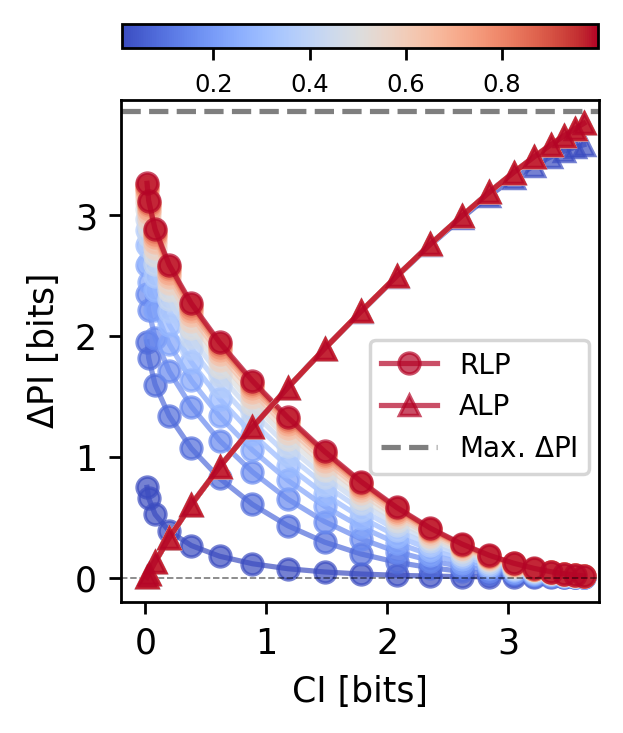

In [4]:
# Delta PI vs CI
fig, ax = plt.subplots(figsize=(3, 3), dpi = 250)

win_sizes_fractions = [win_sizes[i]/n_cells for i in range(len(win_sizes))]
# Normalize window sizes for color intensity
norm_win = plt.Normalize(min(win_sizes_fractions), max(win_sizes_fractions))
colors_win = cm.coolwarm(norm_win(win_sizes_fractions))  # Generate shades of red


#------------------------   Plots   -------------------------#
for i_win, win_size in enumerate(win_sizes[:-2]):
    plt.plot(CIs, Delta_PIs_RLP_theory[:, i_win], color=colors_win[i_win], alpha=0.7, marker='o')
    plt.plot(CIs, Delta_PIs_ALP_theory[:, i_win], color=colors_win[i_win], alpha=0.7, marker='^', zorder=10)

plt.plot(CIs, Delta_PIs_RLP_theory[:, -1], color=colors_win[-1], alpha=0.7, marker='o', label = 'RLP')
plt.plot(CIs, Delta_PIs_ALP_theory[:, -1], color=colors_win[-1], alpha=0.7, marker='^', label = 'ALP',zorder=11)
#------------------------------------------------------------#

ax.set_xlabel('CI [bits]')
ax.set_ylabel(r'$\Delta$PI [bits]')
plt.axhline(y = 0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axhline(y = np.log2(n_cells) - PIs[0], linestyle='--', color='k', zorder=12, alpha=0.5, label = r'Max. $\Delta$PI')
plt.xlim(-0.2, 3.75)
plt.ylim(-0.2, 3.95)

# make colorbar for window sizes
scalarmappaple_win = cm.ScalarMappable(norm=norm_win, cmap='coolwarm')
scalarmappaple_win.set_array([])
cbar = plt.colorbar(scalarmappaple_win, fraction=0.0412, pad=0.09, ax=ax,
                    orientation='horizontal', location='top')

cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.tick_params(labelsize=7) 
cbar.ax.set_xticks([0.2, 0.4, 0.6, 0.8])


ax.set_aspect('equal', adjustable='box')

plt.legend(bbox_to_anchor=(0.75, .55), loc='upper center', fontsize=8)

# plt.savefig('../results/figures/RLP_and_ALP.pdf', bbox_inches='tight', transparent=True)

---
## CI and correlation strength and lenght

In [5]:
sigma_tot = sigma_ref

sigma_ratios = np.logspace(np.log10(0.5), np.log10(15), 30)

covariance_kernel = 'SimpleExponential'
x_positions = np.linspace(0, L, n_cells)

corr_lengths = np.logspace(-0.5, 3, 20)

derivative_g = - mu_S/(lamb) * np.exp(-np.arange(n_cells)/(lamb*(n_cells/L)))

CIs = np.zeros((len(corr_lengths), len(sigma_ratios)))
PIs = np.zeros((len(corr_lengths), len(sigma_ratios)))
Ixxstar_theory = np.zeros((len(corr_lengths), len(sigma_ratios)))
delta_PIs_RLP_full = np.zeros((len(corr_lengths), len(sigma_ratios)))
delta_PIs_ALP_full = np.zeros((len(corr_lengths), len(sigma_ratios)))

CIs_zero_si = np.zeros(len(corr_lengths))
PIs_zero_si = np.zeros(len(corr_lengths))

In [6]:
for i_cor, corr_length in tqdm(enumerate(corr_lengths)):
    sigma_int = 0.0000001
    sigma_ext = sigma_tot - sigma_int
    G = pci.samples_from_gp_exponential_profile(x_positions[:, np.newaxis], covariance_kernel, corr_length,
                                                    delta_x, sigma_ext, sigma_int, mu_S, lamb, n_embryos)

    ## compute true theoretical covariance
    cov = np.zeros((n_cells, n_cells))
    for i in range(n_cells):
        for j in range(n_cells):
            if covariance_kernel == 'SimpleExponential':
                cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-np.abs(i-j)/corr_length)) * np.exp(-(i+j)*delta_x/lamb)
            elif covariance_kernel == 'SquaredExponential':
                cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-(i-j)**2/(2*corr_length**2))) * np.exp(-(i+j)*delta_x/lamb)
            else:
                raise ValueError('covariance kernel not recognized')
    _,CIs_zero_si[i_cor] = pci.compute_CI(G, cov=cov)
    _,_,PIs_zero_si[i_cor] = pci.compute_PI(G, 500)


    for i_r, sigma_ratio in enumerate(sigma_ratios):
        sigma_int = sigma_tot / np.sqrt(1 + sigma_ratio**2)
        sigma_ext = sigma_tot * sigma_ratio / np.sqrt(1 + sigma_ratio**2)
        
        G = pci.samples_from_gp_exponential_profile(x_positions[:, np.newaxis], covariance_kernel, corr_length,
                                                    delta_x, sigma_ext, sigma_int, mu_S, lamb, n_embryos)

        ## compute true theoretical covariance
        cov = np.zeros((n_cells, n_cells))
        for i in range(n_cells):
            for j in range(n_cells):
                if covariance_kernel == 'SimpleExponential':
                    cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-np.abs(i-j)/corr_length)) * np.exp(-(i+j)*delta_x/lamb)
                elif covariance_kernel == 'SquaredExponential':
                    cov[i,j] = (sigma_int**2 * (i==j) + sigma_ext**2 * np.exp(-(i-j)**2/(2*corr_length**2))) * np.exp(-(i+j)*delta_x/lamb)
                else:
                    raise ValueError('covariance kernel not recognized')
                
        inv_pos_errs_local = np.zeros(n_cells)
        for i_cell in range(n_cells):
            inv_pos_errs_local[i_cell] = derivative_g[i_cell]**2 / cov[i_cell, i_cell] 

        Ixxstar_theory[i_cor, i_r] = np.log2(L/(np.sqrt(2*np.pi*np.e))) + 0.5 * np.mean(np.log2(inv_pos_errs_local))
        _,CIs[i_cor, i_r] = pci.compute_CI(G, cov=cov)
        _,_,PIs[i_cor, i_r] = pci.compute_PI(G, 500)

        # compute delta PIs for RLP and ALP in the case of full embryo info
        n_neigh = n_cells
        invpos_errs = np.zeros(n_cells)
        delta_PIs_ALP_full[i_cor, i_r] = 0.0
        for i_cell in range(n_cells):
            start = max(0, i_cell - n_neigh)
            end = min(n_cells, i_cell + n_neigh + 1)  # note: end is non-inclusive
            S_indices = np.arange(start, end)
            i_in_S = np.where(S_indices == i_cell)[0][0]
            invpos_errs[i_cell] = np.dot(derivative_g[S_indices], np.dot(np.linalg.inv(cov[S_indices][:, S_indices]), derivative_g[S_indices])) #+ 2 * len(S_indices)/(lamb**2)

            ## ----------------------------------------------
            delta_PIs_ALP_full[i_cor, i_r] += 0.5/n_cells * ( np.log2(cov[i_cell, i_cell]) + np.log2(np.linalg.inv(cov[S_indices][:, S_indices])[i_in_S, i_in_S])) 
        delta_PIs_RLP_full[i_cor, i_r] = np.log2(L/(np.sqrt(2*np.pi*np.e))) + 0.5* np.mean(np.log2(invpos_errs)) - Ixxstar_theory[i_cor, i_r]

20it [01:06,  3.30s/it]


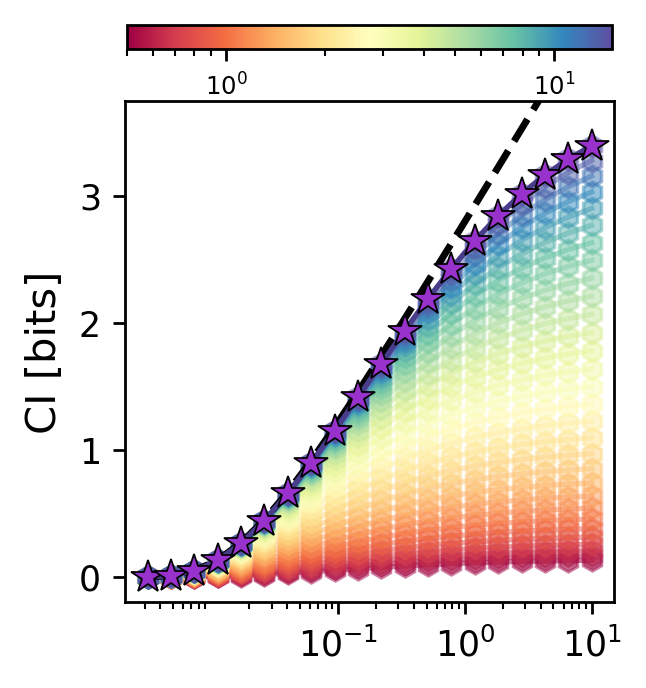

In [7]:
fig, ax = plt.subplots(figsize=(3, 3), dpi = 250)

norm_si = LogNorm(vmin=min(sigma_ratios), vmax=max(sigma_ratios))

colors_si = cm.Spectral(norm_si(sigma_ratios))  # Generate shades of red
ax.set_xscale('log')

plt.plot(corr_lengths/n_cells, CIs_zero_si, color='k', alpha=0.99, zorder=20, ls='--', label=r'$\sigma_{int} = 0$', lw=2)

for i_r, sigma_int in enumerate(sigma_ratios):
    plt.plot(corr_lengths/n_cells, CIs[:,i_r], color=colors_si[i_r], alpha=0.5, marker='h')

plt.plot(corr_lengths/n_cells, CIs[:,-1], color='darkslateblue', lw=1.5, marker='*',zorder=30, ms=10, mec='k', mew=0.5, mfc='darkorchid' )

plt.ylabel('CI [bits]', fontsize=12)
plt.xticks([0.1, 1, 10])
plt.yticks([0, 1, 2, 3])

plt.ylim(-0.2, 3.75)

scalarmappaple_si = cm.ScalarMappable(norm=norm_si, cmap='Spectral')
scalarmappaple_si.set_array([])
cbar = plt.colorbar(scalarmappaple_si, fraction=0.042, pad=0.09, ax=ax,
                    orientation='horizontal', location='top')

cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.tick_params(labelsize=7) 
# cbar.ax.set_xticks([0.2, 0.4, 0.6, 0.8])

ax.set_aspect('equal', adjustable='box')

# plt.legend(fontsize=9)

# plt.savefig('../../figures/CI_vs_corr_length.pdf', bbox_inches='tight', transparent=True)

---
### Supplementary Figure S1

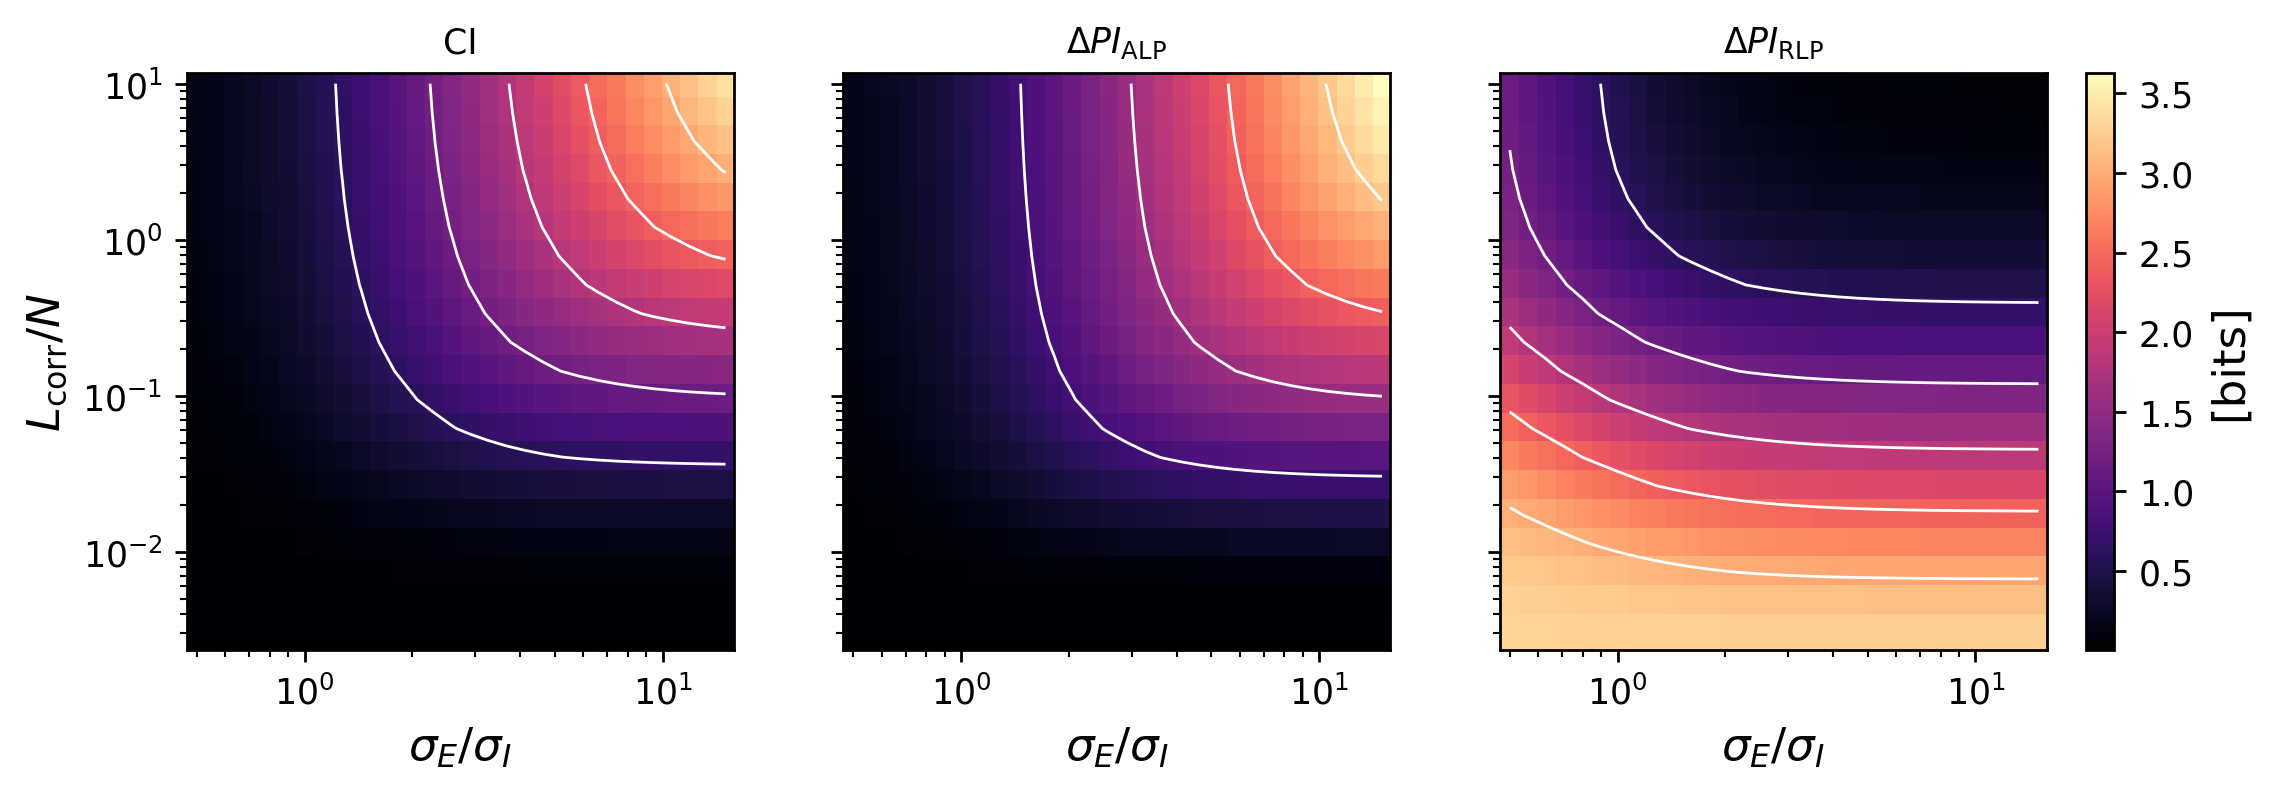

In [8]:
# ---Compute global color limits ---
vmin = min(np.min(CIs), np.min(delta_PIs_ALP_full), np.min(delta_PIs_RLP_full))
vmax = max(np.max(CIs), np.max(delta_PIs_ALP_full), np.max(delta_PIs_RLP_full))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(1, 3, figsize=(10, 3), dpi=250, sharex=True, sharey=True)

datasets = [CIs, delta_PIs_ALP_full, delta_PIs_RLP_full]
titles = ['CI', r'$\Delta PI_{{\rm ALP}}$', r'$\Delta PI_{{\rm RLP}}$']

# ---Plot using pcolormesh + contour overlay ---
for ax, data, title in zip(axs, datasets, titles):
    # pcolormesh
    pcm = ax.pcolormesh(sigma_ratios, corr_lengths/n_cells, data,
                        norm=norm, cmap='magma', shading='auto')

    # contour overlay
    cs = ax.contour(sigma_ratios, corr_lengths/n_cells, data,
                    levels=5, colors='white', linewidths=0.8)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r'$\sigma_{E}/\sigma_{I}$', fontsize=13)
    if ax == axs[0]:
        ax.set_ylabel(r'$L_{{\rm corr}}/N$', fontsize=13)

# ---Shared colorbar ---
cbar = fig.colorbar(pcm, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('[bits]', fontsize=13)

# plt.savefig('../../figures/CI_and_delta_PI_heatmaps.png', bbox_inches='tight', transparent=True, dpi=450)